Fução Borradez

In [ ]:
import cv2
import numpy as np
from PIL import Image

# calcular_fator_borradez(data_or_path)
# - Entrada: caminho para imagem (str) ou array NumPy (RGB ou grayscale).
# - Saída: float representando o "fator de borradez" calculado (maior = mais borrada),
#          ou None em caso de erro/arquivo inválido.
#
# Passos principais:
# 1) Ler a imagem (cv2 preferencialmente; fallback para PIL para WebP/formatos especiais).
# 2) Converter para grayscale caso necessário e normalizar para [0,1].
# 3) Subtrair a média para remover componente DC (evita pico dominante na autocorrelação).
# 4) Calcular FFT 2D -> espectro de potência.
# 5) Medir a área acima de metade do pico (proxy para FWHM).
# 6) Normalizar pela área da imagem e retornar o valor escalado.

def calcular_fator_borradez(data_or_path):
    """Calcula um indicador numérico de borradez da imagem."""
    img = None
    # Se foi passado um caminho, tenta abrir com cv2; se falhar, tenta com PIL
    if isinstance(data_or_path, str):
        img = cv2.imread(data_or_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            try:
                # PIL suporta .webp e outros formatos menos comuns
                pil = Image.open(data_or_path).convert('L')
                img = np.array(pil)
            except Exception:
                return None
    else:
        # Se recebeu um array (ex.: imagem já carregada), garante formato adequado
        arr = np.asarray(data_or_path)
        if arr.ndim == 3:
            # Converte RGB/BGR para grayscale
            arr = cv2.cvtColor(arr, cv2.COLOR_BGR2GRAY)
        img = arr

    if img is None:
        return None

    # Converter para float e normalizar
    img = img.astype(np.float32)
    img_normalizada = img / 255.0

    # Remover componente DC (média) para evitar artefatos na FFT/autocorrelação
    img_normalizada = img_normalizada - np.mean(img_normalizada)

    # FFT 2D e cálculo de espectro de potência
    f = np.fft.fft2(img_normalizada)
    espectro_potencia = np.abs(f) ** 2

    # Métrica: área de pontos acima de 50% do pico (proxy simples para FWHM)
    pico_maximo = np.max(espectro_potencia)
    if pico_maximo == 0:
        return 0.0
    area_pico = np.sum(espectro_potencia > (0.5 * pico_maximo))

    # Normalizar pela resolução da imagem para tornar a métrica comparável
    altura, largura = img.shape
    area_total_imagem = altura * largura
    fator_borradez = (area_pico / area_total_imagem) * 100000

    # Retorna valor float (mais alto -> área de pico maior -> imagem mais borrada)
    return float(fator_borradez)


Programa principal para testar a borradez

Média dos resultados em Imagens_Boas: 0.42359247945707323
Média dos resultados em Imagens_Ruins: 0.28645833333333337


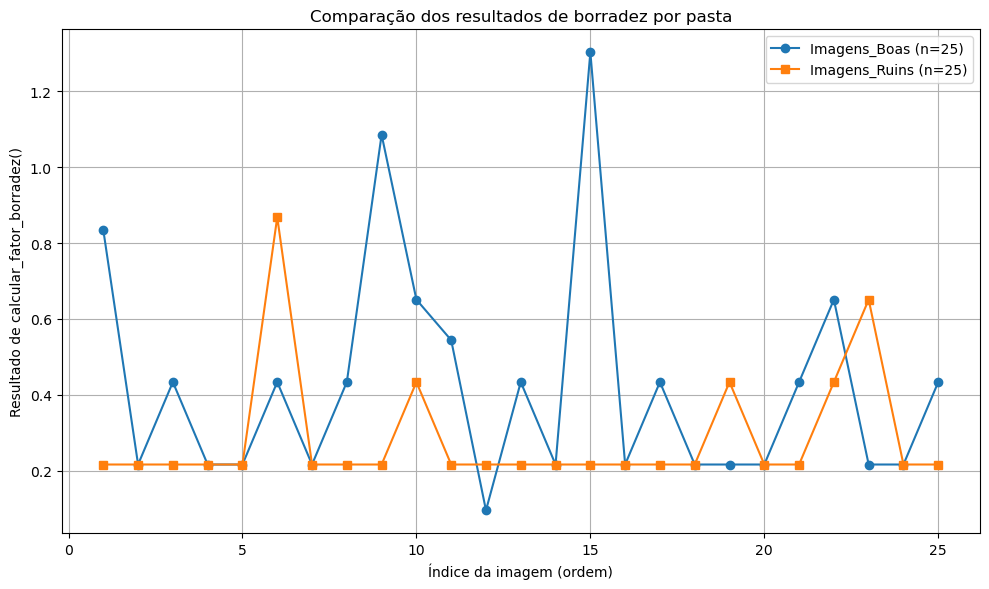

In [28]:
# Célula principal: percorre duas pastas, aplica `calcular_fator_borradez` em cada imagem e plota resultados
from pathlib import Path
import matplotlib.pyplot as plt

# Extensões aceitas (adicionado .webp porque suas pastas contêm esse formato)
ALLOWED_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}


def run_on_folder(folder_path):
    """Percorre uma pasta (recursivamente) e aplica `calcular_fator_borradez` em cada arquivo.

    Retorna duas listas: `results` com os valores (float) e `names` com nomes dos arquivos.
    Arquivos inválidos ou que falharem no processamento são ignorados (e uma mensagem é impressa).
    """
    p = Path(folder_path)
    # rglob para incluir subpastas; filtra por extensão
    files = sorted([f for f in p.rglob('*') if f.suffix.lower() in ALLOWED_EXTS])
    results = []
    names = []
    for f in files:
        try:
            # Chama a função principal de borradez com o caminho do arquivo
            res = calcular_fator_borradez(str(f))
        except Exception as e:
            print(f"Ignorado {f}: {e}")
            continue
        if res is None:
            # Se a função não conseguiu ler/processar o arquivo, avisa e pula
            print(f"Falha ao processar {f}")
            continue
        try:
            results.append(float(res))
        except Exception:
            results.append(res)
        names.append(f.name)
    return results, names


# Pastas relativas à raiz do projeto (substitua se quiser outros caminhos)
from pathlib import Path as _P
project_root = _P('.').resolve()
folder1 = str(project_root / 'Imagens_Boas')
folder2 = str(project_root / 'Imagens_Ruins')

# Executa processamento nas duas pastas
res1, names1 = run_on_folder(folder1)
res2, names2 = run_on_folder(folder2)

# Preparar e plotar
plt.figure(figsize=(10, 6))
plotted = False
# Desenha uma linha por pasta; o eixo x é apenas o índice da imagem na ordem encontrada
if res1:
    plt.plot(range(1, len(res1) + 1), res1, marker='o', label=f"{Path(folder1).name} (n={len(res1)})")
    plotted = True
    print(f"Média dos resultados em {Path(folder1).name}: {sum(res1)/len(res1)}")
else:
    print(f"Nenhuma imagem encontrada em: {folder1}")
if res2:
    plt.plot(range(1, len(res2) + 1), res2, marker='s', label=f"{Path(folder2).name} (n={len(res2)})")
    plotted = True
    print(f"Média dos resultados em {Path(folder2).name}: {sum(res2)/len(res2)}")
else:
    print(f"Nenhuma imagem encontrada em: {folder2}")

# Rótulos e estilo do gráfico
plt.xlabel('Índice da imagem (ordem)')
plt.ylabel('Resultado de calcular_fator_borradez()')
plt.title('Comparação dos resultados de borradez por pasta')
if plotted:
    plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
